In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [26]:
df = pd.read_csv('tasks 2\\ebay_printer.csv')
# df1 = pd.read_csv('tasks 2\\ebay_printer.csv')



In [27]:
# have all columns names saved in lower case
df.columns = df.columns.str.lower()

In [28]:
# rename a column to add the currency in the shipping and the price column
df.rename(columns={"shipping": "shipping+deliveryfee$$"}, inplace=True)
df.rename(columns={"price": "price$$"}, inplace=True)

# rename the origin location column to show this is where the package is from
df.rename(columns={"location": "origin_location"}, inplace=True)

In [ ]:
# # # removing dollar sign 
 
 
df["watch count"] = df["watch count"].str.replace("+", "", regex=False)
df["watch count"] = df["watch count"].str.replace(" watchers", "", regex=False)






In [30]:
# check duplicates in df
df.duplicated().sum()

# drop all duplicates in the dataset
df.drop_duplicates(inplace=True)

In [ ]:
# Function to check and replace range with mean
def replace_range_with_mean(value):
    # Check if the value matches the range format (e.g., "23.99 to 92.99")
    match = re.match(r"([\d.]+)to([\d.]+)", value)
    
    if match:
        # Extract the two numbers
        num1 = float(match.group(1))
        num2 = float(match.group(2))
        
        # Calculate the mean of the two numbers
        mean_value = (num1 + num2) / 2
        
        # Return the mean value as a string with 2 decimal points
        return f"{mean_value:.2f}"
    
    # Return the value unchanged if it is not a range
    return value

# Apply the function to the 'price' column
df["price$$"] = df["price$$"].apply(replace_range_with_mean)



In [66]:
df.tail(20)

,title,subtitle,price$$,shipping+deliveryfee$$,origin_location,watch count,seller info,link,image url
10694,Small Quick Mobile! Printer USB HP Deskjet 470...,Pre-Owned,98.78,77.99,Germany,0.0,"alles4pc! (93,360) 99.5%",https://www.ebay.com/itm/275478827289,https://i.ebayimg.com/images/g/Yd8AAOSwPb1ctF~...
10695,Datamax E-4205A E-Class USB Direct Thermal Lab...,Pre-Owned,59.99,93.85,United States,0.0,"ocean-tech (51,657) 99.7%",https://www.ebay.com/itm/126445264879,https://i.ebayimg.com/images/g/nD4AAOSwwWpmJsF...
10696,Rongta RP410 Direct Thermal Desktop Printer fo...,"Network LAN 10/100 Mbps Ethernet , WiFi & USB",224.98,100.61,United States,0.0,"banana_barcode (2,405) 100%",https://www.ebay.com/itm/154438387793,https://i.ebayimg.com/images/g/ynsAAOSwt8NgkB~...
10697,Compaq ij650 Series Color Inkjet printer 2400d...,Open Box,79.99,147.29,United States,0.0,"sdslba228 (11,031) 99.3%",https://www.ebay.com/itm/266206121158,https://i.ebayimg.com/images/g/YUIAAOSw72FkL5r...
10698,EC-JET EC-JET300 Continuous Inkjet Printer - A...,Parts Only,433.19,293.31,United States,0.0,"ntc_tech (34,590) 99.7%",https://www.ebay.com/itm/154826435670,https://i.ebayimg.com/images/g/ufcAAOSw1zph~GV...
10699,Intermec PD43 Thermal Label Printer (PD43AG310...,Pre-Owned,279.99,214.17,United States,0.0,"tech-world43228 (45,462) 98%",https://www.ebay.com/itm/156563744327,https://i.ebayimg.com/images/g/OZMAAOSwSkJnUdc...
10700,Zebra Z4M Plus Industrial Label Printer,Pre-Owned,282.32,0.00,Australia,0.0,"koalabay_52 (4,487) 99.4%",https://www.ebay.com/itm/386216387583,https://i.ebayimg.com/images/g/jI8AAOSwMRBlEo7...
10701,BROTHER ALL IN ONE PRINTER MFC-J280W INK JET ...,Pre-Owned,86.77,323.08,United States,0.0,"i-reutilize (2,940) 94.6%",https://www.ebay.com/itm/226540527304,https://i.ebayimg.com/images/g/UIgAAOSwLypnVeb...
10702,Canon Bubble Jet K10156 Portable Printer *no p...,Pre-Owned,30.00,79.87,United States,0.0,"owensbrand (2,331) 99.5%",https://www.ebay.com/itm/183312832980,https://i.ebayimg.com/images/g/9wYAAOSwEjlbQMk...
10703,P525L YMCO Heat Sublimation Type Photo Printer...,Brand New,749.32,124.02,China,7.0,youneed48 (807) 96.4%,https://www.ebay.com/itm/186132164967,https://i.ebayimg.com/images/g/cV4AAOSwso9lNeS...


In [35]:
#replace a free international shipping with a zero
df["shipping+deliveryfee$$"] = df["shipping+deliveryfee$$"].replace("Free International Shipping", "0")
df["shipping+deliveryfee$$"] = df["shipping+deliveryfee$$"].replace("Shipping not specified", "0")



In [61]:
df.dtypes


title                      object
subtitle                   object
price$$                   float64
shipping+deliveryfee$$    float64
origin_location            object
watch count               float64
seller info                object
link                       object
image url                  object
dtype: object

In [60]:
# # change dtype of price and shipping+deliveryfee columns to float
df["price$$"] = df["price$$"].astype(float)
df["watch count"] = df["watch count"].astype(float)
df["shipping+deliveryfee$$"] = df["shipping+deliveryfee$$"].astype(float)

In [62]:
# total number of rows with nan values in the dataset
totaln = df.isna().sum()

# total number of rows in the dataset
totalt = df.shape[0]
print(totalt / totaln)



title                     inf
subtitle                  inf
price$$                   inf
shipping+deliveryfee$$    inf
origin_location           inf
watch count               inf
seller info               inf
link                      inf
image url                 inf
dtype: float64


In [39]:
# drop nan values in the seller info column
df.dropna(subset=["seller info"], inplace=True)

In [58]:
# replace NaN values with zero in watch count column
df["watch count"] = df["watch count"].fillna(0)

In [63]:
df['price$$'].describe()

count     8343.000000
mean       170.883625
std        632.550091
min          0.990000
25%         32.550000
50%         65.450000
75%        139.340000
max      17628.000000
Name: price$$, dtype: float64

In [64]:
df['shipping+deliveryfee$$'].describe()

count     8343.000000
mean       158.759601
std        234.547529
min          0.000000
25%         46.130000
50%        110.420000
75%        237.825000
max      10031.080000
Name: shipping+deliveryfee$$, dtype: float64

In [65]:
df['watch count'].describe()

count    8343.000000
mean        0.644732
std         4.520459
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       117.000000
Name: watch count, dtype: float64

In [67]:
# unique watch count
df['watch count'].unique()

array([  0.,  26.,  10.,  32.,  20.,  76.,   8.,   6.,  16.,  21.,  19.,
        52.,  13.,  23.,  14.,  27.,  12.,  33.,  59.,  29.,  53.,   5.,
         3.,  38.,   9.,  34.,   2.,   1.,   7.,  46.,  11.,  17.,  15.,
        40.,  25.,  30., 114.,   4.,  56.,  74.,  24.,  49.,  18.,  51.,
        83.,  42.,  28.,  35.,  64.,  31.,  41., 103.,  48., 117.,  71.,
        65.])

In [68]:
# whats the mode in the watch count column
df['watch count'].mode()

0    0.0
Name: watch count, dtype: float64

In [69]:
df.head()

,title,subtitle,price$$,shipping+deliveryfee$$,origin_location,watch count,seller info,link,image url
0,Canon Printer-wireless-All in One-Home Busines...,Open Box,40.99,138.70,United States,0.0,"photodeals1 (17,630) 97.4%",https://www.ebay.com/itm/195367751796,https://i.ebayimg.com/images/g/CSkAAOSwRMhjLJI...
1,"HP DeskJet 2855e All-in-One Inkjet Printer, Co...",Free $5 instant ink ecard with select printer ...,59.99,131.13,United States,0.0,"officialhpstore (61,701) 98.9%",https://www.ebay.com/itm/156198026960,https://i.ebayimg.com/images/g/6OYAAOSwSpNnMej...
2,"Canon Pixma Inkjet Color Printer, High Resolut...",Open Box,36.99,176.52,United States,0.0,"photodeals1 (17,630) 97.4%",https://www.ebay.com/itm/195368121055,https://i.ebayimg.com/images/g/FeAAAOSwamtjhL2...
3,HP LaserJet 4350N Laser Printer - COMPLETELY R...,Pre-Owned,395.00,30.43,United States,0.0,"midwestdynamics (5,043) 100%",https://www.ebay.com/itm/333308246802,https://i.ebayimg.com/images/g/lfQAAOSwsW9YwxZ...
4,New ListingFUJIFILM Instax Mini Link 1 Smartph...,Pre-Owned,44.95,34.34,United States,0.0,"itsvintage88 (2,917) 99.2%",https://www.ebay.com/itm/375986746296,https://i.ebayimg.com/images/g/35IAAOSwGbNnqn2...


In [74]:

# Get the mode
mode_value = df['shipping+deliveryfee$$'].mode()[0]  # Taking the first mode (if multiple modes exist)

# Count how many times the mode appears
mode_count = df['shipping+deliveryfee$$'].value_counts()[mode_value]

print(f"Mode: {mode_value}, Count: {mode_count}")

Mode: 0.0, Count: 440


{'whiskers': [<matplotlib.lines.Line2D at 0x1abcefbc2d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1abcefbc550>,
 'boxes': [<matplotlib.lines.Line2D at 0x1abcefbc190>],
 'medians': [<matplotlib.lines.Line2D at 0x1abcefbc7d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1abcefbc910>],
 'means': []}

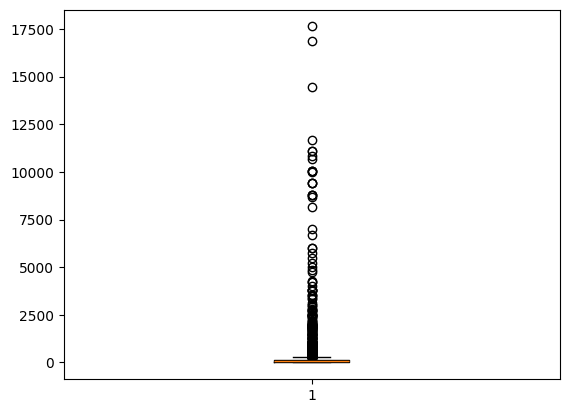

In [ ]:
# draw a boxplot to show the distribution of the price column
plt.boxplot(df["price$$"])

In [83]:
# return all those columns and rows wheer price is greater than 1000    
df[df["price$$"] > 7500]

,title,subtitle,price$$,shipping+deliveryfee$$,origin_location,watch count,seller info,link,image url
849,DR panel radiography wireless,Pre-Owned,11111.00,1000.00,United States,0.0,"xraychicago (2,719) 100%",https://www.ebay.com/itm/326436964059,https://i.ebayimg.com/images/g/Al0AAOSwsYNnqWm...
1655,Vertical Automatic 2 in 1 3D Printer For Wall ...,Brand New,10031.50,313.70,China,2.0,"18beautifulday (3,593) 98.6%",https://www.ebay.com/itm/145689953213,https://i.ebayimg.com/images/g/KSwAAOSwjyZmA7y...
2013,New 4.5*3m 7D Wall Injekt Printer Dual Head DX...,Brand New,11657.87,186.03,China,11.0,bestit-32 (561) 98.8%,https://www.ebay.com/itm/364650382487,https://i.ebayimg.com/images/g/ansAAOSwSupljny...
2427,3 in 1 3D Vertical Wall Printer Machine/Mural ...,Brand New,10037.77,94.11,China,0.0,"motor*pro (9,680) 97%",https://www.ebay.com/itm/267070343604,https://i.ebayimg.com/images/g/0MQAAOSwvmtnSAJ...
2497,digital DR panel radiography wireless,Pre-Owned,11111.00,1000.00,United States,0.0,"xraychicago (2,719) 100%",https://www.ebay.com/itm/326436968449,https://i.ebayimg.com/images/g/Nb8AAOSw5dlnqWx...
3084,UV Printer Glass Metal Ceramic Cylinder Wine B...,Brand New,10853.39,94.11,China,0.0,"motor*pro (9,680) 97%",https://www.ebay.com/itm/256756924602,https://i.ebayimg.com/images/g/8cwAAOSwgutnZRk...
3144,New 2.5*6m 5D Wall Injekt Printer Dual-Head DX...,Brand New,8770.42,94.11,China,0.0,wouldrecommend (332) 99%,https://www.ebay.com/itm/386983838674,https://i.ebayimg.com/images/g/vzcAAOSwKPBmOE0...
3256,IDEXX Digital Imaging veterinary DR panel,Pre-Owned,9999.00,1000.00,United States,0.0,"xraychicago (2,719) 100%",https://www.ebay.com/itm/326430905654,https://i.ebayimg.com/images/g/5GEAAOSw7B9no-4...
3525,veterinary DR panel wireless,Brand New,14444.00,1000.00,United States,0.0,"xraychicago (2,719) 100%",https://www.ebay.com/itm/326433011474,https://i.ebayimg.com/images/g/kEkAAOSw2JVnph3...
5495,New 2.5*6m 5D Wall injekt printer dual head DX...,Brand New,8776.70,94.11,China,0.0,bestit-32 (561) 98.8%,https://www.ebay.com/itm/364524033026,https://i.ebayimg.com/images/g/q40AAOSwn4VlJl5...


{'whiskers': [<matplotlib.lines.Line2D at 0x2179f428550>,
 'caps': [<matplotlib.lines.Line2D at 0x2179f428690>,
 'boxes': [<matplotlib.lines.Line2D at 0x2179f4242d0>],
 'medians': [<matplotlib.lines.Line2D at 0x2179f428910>],
 'fliers': [<matplotlib.lines.Line2D at 0x2179f428a50>],
 'means': []}

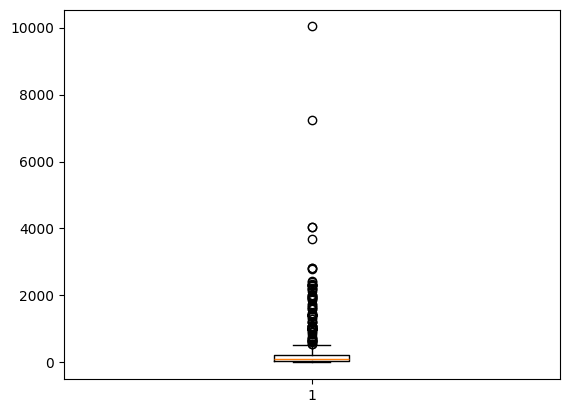

In [78]:
# draw a boxplot to show the distribution of the price column
plt.boxplot(df["shipping+deliveryfee$$"])

In [84]:
# return all those columns and rows wheer price is greater than 1000    
df[df["shipping+deliveryfee$$"] > 2300]

,title,subtitle,price$$,shipping+deliveryfee$$,origin_location,watch count,seller info,link,image url
519,SATO M-8485Se Barcode Printer - Parts/Repair E...,Parts Only,477.99,2809.03,United States,0.0,"vermontindustrialsupply (1,687) 99%",https://www.ebay.com/itm/156405072895,https://i.ebayimg.com/images/g/rV4AAOSw1qRm4yt...
1203,NEW DEC VINTAGE LJ250 COMPANION COLOR PRINTER ...,Brand New,114.99,2789.03,United States,3.0,"ssequipment (4,760) 99.7%",https://www.ebay.com/itm/114722776318,https://i.ebayimg.com/images/g/1FYAAOSwcOBgSj2...
1398,HP LaserJet Managed E50145 B/W Mono Laser Prin...,Pre-Owned,168.00,2309.03,United States,2.0,first_office_supplies (32) 97.1%,https://www.ebay.com/itm/395903008534,https://i.ebayimg.com/images/g/f4cAAOSw6QpnNbE...
2541,Canon LASERCLASS Fax 710 Workgroup Laser Printer,Brand New,259.00,4057.76,United States,0.0,noveltiesstore (530) 100%,https://www.ebay.com/itm/167169363836,https://i.ebayimg.com/images/g/-vYAAOSwza5nWhM...
2978,Lexmark MX522 All in one Printer,Pre-Owned,149.99,2835.43,United States,0.0,"thecobracache (15,373) 99.2%",https://www.ebay.com/itm/135201957711,https://i.ebayimg.com/images/g/EnMAAOSwqptmxLh...
4042,Epson DFX-8000 Dot Matrix Printer,Parts Only,199.99,2399.43,United States,0.0,"electriccoyote (4,987) 100%",https://www.ebay.com/itm/146272133062,https://i.ebayimg.com/images/g/xw0AAOSwIuBmjac...
4713,ZEBRA 105SL 10500-2001-0030 NSNP,Open Box,1908.00,2305.78,United States,0.0,"industrial_blueline_special (2,188) 99.7%",https://www.ebay.com/itm/167065347917,https://i.ebayimg.com/images/g/f5cAAOSwXr9nKQb...
5709,Epson Workforce 645 Wi-Fi Print Scan Copy Fax,Pre-Owned,59.99,2307.78,United States,0.0,"treasurefinderstn (1,932) 99.7%",https://www.ebay.com/itm/315891684641,https://i.ebayimg.com/images/g/Kg4AAOSwY-1mxm6...
7756,ATN Label Print Applicator 571A/595A2 571 A 59...,Pre-Owned,2064.57,7229.60,Germany,0.0,"maaslos-gut_de (21,875) 100%",https://www.ebay.com/itm/405512278476,https://i.ebayimg.com/images/g/U2MAAOSwlCdnnKD...
8161,HP LaserJet Pro 400 M401dne Workgroup Laser P...,Pre-Owned,75.00,2431.87,United States,0.0,fabtechproducts (141) 86.7%,https://www.ebay.com/itm/176513513593,https://i.ebayimg.com/images/g/cS8AAOSwPDZmtME...


In [89]:
# drop all values where the price is greater than 1000
df_cleaned = df[df["price$$"] <= 7500]

# drop all values where the price is greater than 1000
df_cleaned = df[df["shipping+deliveryfee$$"] <= 2500]


{'whiskers': [<matplotlib.lines.Line2D at 0x2179f939810>,
 'caps': [<matplotlib.lines.Line2D at 0x2179f939a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x2179f9396d0>],
 'medians': [<matplotlib.lines.Line2D at 0x2179f939d10>],
 'fliers': [<matplotlib.lines.Line2D at 0x2179f939e50>],
 'means': []}

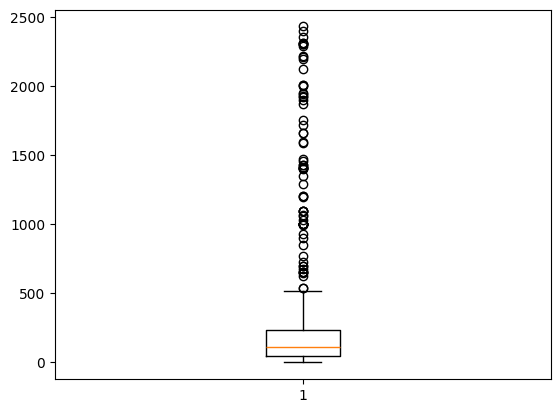

In [86]:
# draw a boxplot to show the distribution of the price column
plt.boxplot(df_cleaned["shipping+deliveryfee$$"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2179f971310>,
 'caps': [<matplotlib.lines.Line2D at 0x2179f971590>,
 'boxes': [<matplotlib.lines.Line2D at 0x2179f9711d0>],
 'medians': [<matplotlib.lines.Line2D at 0x2179f971810>],
 'fliers': [<matplotlib.lines.Line2D at 0x2179f971950>],
 'means': []}

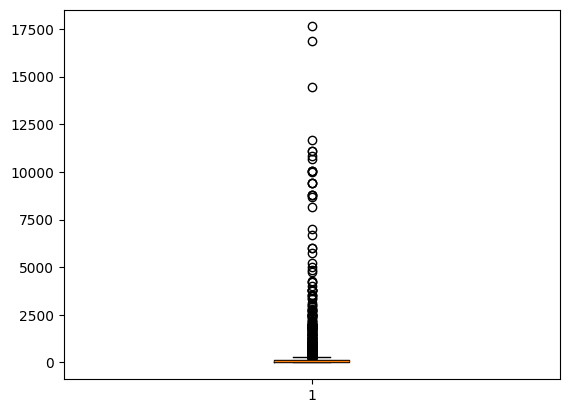

In [87]:
# draw a boxplot to show the distribution of the price column
plt.boxplot(df_cleaned["price$$"])

In [109]:
# Remove emojis
df_cleaned["title"] = df_cleaned["title"].astype(str).apply(lambda x: x.encode('ascii', 'ignore').decode('ascii'))
df_cleaned["subtitle"] = df_cleaned["subtitle"].astype(str).apply(lambda x: x.encode('ascii', 'ignore').decode('ascii'))



C:\Users\Administrator\AppData\Local\Temp\ipykernel_9036\3299876844.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["title"] = df_cleaned["title"].astype(str).apply(lambda x: x.encode('ascii', 'ignore').decode('ascii'))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9036\3299876844.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["subtitle"] = df_cleaned["subtitle"].astype(str).apply(lambda x: x.encode('ascii', 'ignore').decode('ascii'))


In [107]:
df_cleaned['title'] = df_cleaned['title'].str.lower()
df_cleaned['subtitle'] = df_cleaned['subtitle'].str.lower()
df_cleaned['seller info'] = df_cleaned['seller info'].str.lower()



C:\Users\Administrator\AppData\Local\Temp\ipykernel_9036\443586887.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['title'] = df_cleaned['title'].str.lower()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9036\443586887.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['subtitle'] = df_cleaned['subtitle'].str.lower()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9036\443586887.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

In [106]:
df_cleaned.head()

,title,subtitle,price$$,shipping+deliveryfee$$,origin_location,watch count,seller info,link,image url
0,canon printer-wireless-all in one-home busines...,open box,40.99,138.70,United States,0.0,"photodeals1 (17,630) 97.4%",https://www.ebay.com/itm/195367751796,https://i.ebayimg.com/images/g/CSkAAOSwRMhjLJI...
1,"hp deskjet 2855e all-in-one inkjet printer, co...",free $5 instant ink ecard with select printer ...,59.99,131.13,United States,0.0,"officialhpstore (61,701) 98.9%",https://www.ebay.com/itm/156198026960,https://i.ebayimg.com/images/g/6OYAAOSwSpNnMej...
2,"canon pixma inkjet color printer, high resolut...",open box,36.99,176.52,United States,0.0,"photodeals1 (17,630) 97.4%",https://www.ebay.com/itm/195368121055,https://i.ebayimg.com/images/g/FeAAAOSwamtjhL2...
3,hp laserjet 4350n laser printer - completely r...,pre-owned,395.00,30.43,United States,0.0,"midwestdynamics (5,043) 100%",https://www.ebay.com/itm/333308246802,https://i.ebayimg.com/images/g/lfQAAOSwsW9YwxZ...
4,new listingfujifilm instax mini link 1 smartph...,pre-owned,44.95,34.34,United States,0.0,"itsvintage88 (2,917) 99.2%",https://www.ebay.com/itm/375986746296,https://i.ebayimg.com/images/g/35IAAOSwGbNnqn2...


In [111]:
# reset the index of the cleaned dataset
df_cleaned.reset_index(drop=True, inplace=True)

In [112]:
df_cleaned.to_csv('tasks 2\\ebay_printers_cleaned.csv', index=False)